<a href="https://colab.research.google.com/github/Taniya-roy20/ML-PROJECT/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving 07_loan_approval.csv to 07_loan_approval.csv


  ApplicantID  Age  AnnualIncome  LoanAmount  CreditScore  EmploymentYears  \
0       L0001   25         35200       30000          703              7.4   
1       L0002   55         38300      133000          712              2.1   
2       L0003   50         35800       95000          678             10.9   
3       L0004   40         43000      103000          694              5.2   
4       L0005   40         77800       84000          728              3.4   

      Education MaritalStatus PropertyArea SelfEmployed LoanApproved  
0      Graduate       Married        Rural           No            Y  
1      Graduate       Married        Urban           No            N  
2      Graduate       Married    Semiurban          Yes            Y  
3      Graduate       Married    Semiurban           No            N  
4  Not Graduate      Divorced        Urban           No            N  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):


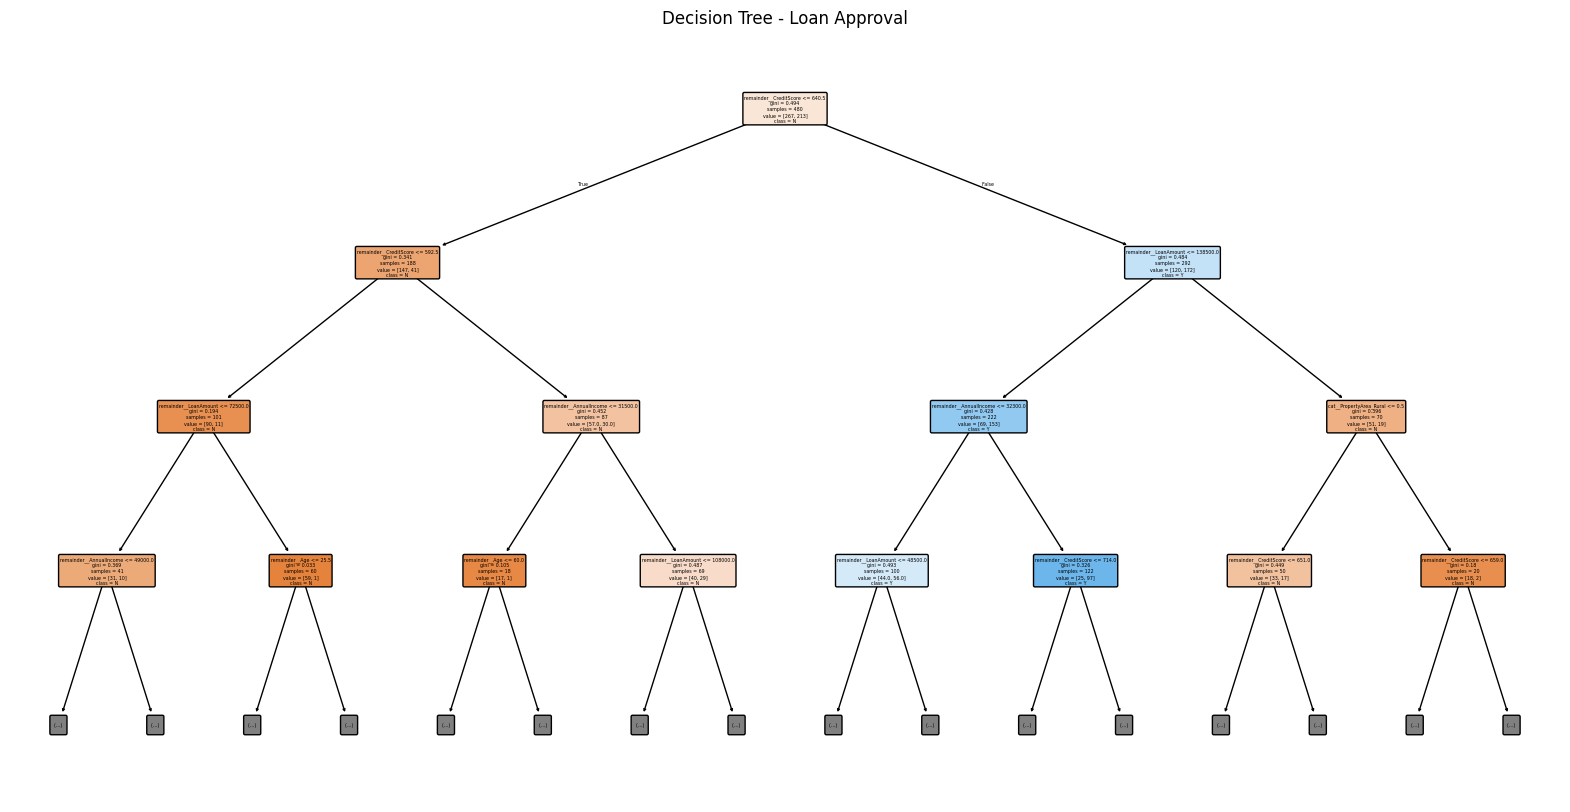

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("07_loan_approval.csv")

print(df.head())
print(df.info())

# Remove ID and separate target
X = df.drop(columns=["ApplicantID", "LoanApproved"])
y = df["LoanApproved"]

# Identify categorical columns
categorical_features = X.select_dtypes(include=["object"]).columns

# One-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         categorical_features)
    ],
    remainder="passthrough"
)

# Decision Tree
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", model)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train
pipeline.fit(X_train, y_train)

# Prediction
y_pred = pipeline.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Decision tree visualization
feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    pipeline.named_steps["classifier"],
    feature_names=feature_names,
    class_names=["N", "Y"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree - Loan Approval")
plt.show()